# Malware Classification with EMBER Dataset

## Overview

This notebook demonstrates building a **malware classifier** using the EMBER 2018 dataset. The workflow includes:

1. **Data Loading**
   - Load training and test features from `.jsonl` files.
   - Extract meaningful features from raw JSON (PE headers, imports, strings, sections).

2. **Feature Engineering**
   - Compute derived features like:
     - Number of sections
     - Average section entropy
     - Number of DLLs and imports
   - Handle missing or malformed data safely.

3. **Data Preprocessing**
   - Apply **log-transform** to skewed numeric features (e.g., file size, number of strings) to compress extreme values.
   - **Normalize** all features using `StandardScaler` to make them comparable in scale.
   - Convert pandas DataFrames into PyTorch tensors for model training.

4. **Dataset Preparation**
   - Create `TensorDataset` and `DataLoader` for batch training.
   - Filter out invalid labels if necessary.

5. **Model Definition**
   - Define a neural network classifier (`MalwareClassifier`) for binary classification (benign vs malicious).

6. **Training Loop**
   - Train the network using `CrossEntropyLoss` and the Adam optimizer.
   - Track batch and epoch losses for monitoring convergence.

7. **Evaluation**
   - Evaluate the trained model on test data.
   - Generate metrics:
     - Accuracy
     - Precision, Recall, F1-score per class
     - Confusion Matrix
   - Visualize results using heatmaps, loss curves, and feature distributions.

8. **Visualizations**
   - Feature distribution before and after log-transform and normalization.
   - Training loss over epochs.
   - Confusion matrix heatmap.
   - Precision/Recall per class bar chart.
   - Optional: PCA/t-SNE projection for 2D visualization of class separation.

---

### Key Insights

- **Log-transform + normalization** significantly improves learning stability by compressing extreme feature values and balancing gradient contributions.
- Without proper preprocessing, the network tends to **overfit large numeric features** and fails to distinguish classes.
- Proper feature scaling allows the network to focus on **patterns across all features**, resulting in balanced classification performance.

# Check Python Environment

In [1]:
import sys
print(sys.executable)

e:\Cyber Repos\AI Cybersecurity Lab\.venv\Scripts\python.exe


# Check PyTorch and GPU

Prints PyTorch version and GPU availability, showing the GPU name if one is available.

In [2]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

torch version: 2.6.0+cu124
cuda available: True
GPU name: NVIDIA GeForce GTX 1650 Ti


# Device Agnostics

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Loading data into code

In [4]:
import os
files = os.listdir(r'E:\Cyber Repos\AI Cybersecurity Lab\Malware Classification\ember2018')
print(files)

['ember_model_2018.txt', 'test_features.jsonl', 'train_features_0.jsonl', 'train_features_1.jsonl', 'train_features_2.jsonl', 'train_features_3.jsonl', 'train_features_4.jsonl', 'train_features_5.jsonl']


# Creating an array of jsonlist datasets to view how data looks like

In [5]:
import pandas as pd

path = r"E:\Cyber Repos\AI Cybersecurity Lab\Malware Classification\ember2018"
ldfs = []

for i in range(6):
    ldf = pd.read_json(os.path.join(path, f"train_features_{i}.jsonl"), lines=True, nrows=5)
    ldfs.append(ldf)
    print(f"--- train_features_{i}.jsonl ---")
    print(ldf.columns.to_list())

  

--- train_features_0.jsonl ---
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']
--- train_features_1.jsonl ---
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']
--- train_features_2.jsonl ---
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']
--- train_features_3.jsonl ---
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']
--- train_features_4.jsonl ---
['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']
--- train_features_5.jsonl ---
['sh

# Investigating sub dictionaries in json files to understand dataset further

In [6]:
import json

with open(os.path.join(path, "train_features_0.jsonl"), 'r') as f:
    row = json.loads(f.readline()) 

print("--- header ---")
print(row['header'])

print("--- section ---")
print(row['section'])

print("--- imports ---")
print(row['imports'])

print("--- strings ---")
print(row['strings'])

print("--- general ---")
print(row['general'])

--- header ---
{'coff': {'timestamp': 1124149349, 'machine': 'I386', 'characteristics': ['CHARA_32BIT_MACHINE', 'RELOCS_STRIPPED', 'EXECUTABLE_IMAGE', 'LINE_NUMS_STRIPPED', 'LOCAL_SYMS_STRIPPED']}, 'optional': {'subsystem': 'WINDOWS_GUI', 'dll_characteristics': [], 'magic': 'PE32', 'major_image_version': 0, 'minor_image_version': 0, 'major_linker_version': 7, 'minor_linker_version': 10, 'major_operating_system_version': 4, 'minor_operating_system_version': 0, 'major_subsystem_version': 4, 'minor_subsystem_version': 0, 'sizeof_code': 26624, 'sizeof_headers': 1024, 'sizeof_heap_commit': 4096}}
--- section ---
{'entry': '.text', 'sections': [{'name': '.text', 'size': 26624, 'entropy': 6.532239617101003, 'vsize': 26134, 'props': ['CNT_CODE', 'MEM_EXECUTE', 'MEM_READ']}, {'name': '.rdata', 'size': 6656, 'entropy': 5.433081641309689, 'vsize': 6216, 'props': ['CNT_INITIALIZED_DATA', 'MEM_READ']}, {'name': '.data', 'size': 512, 'entropy': 1.7424160994148217, 'vsize': 172468, 'props': ['CNT_INI

# Creating a meaningful feature-extraction example to use in training

In [7]:
flat = {
    'label': row['label'],
    'size': row['general']['size'],
    'imports_count': row['general']['imports'],
    'has_signature': row['general']['has_signature'],
    'has_debug': row['general']['has_debug'],
    'string_entropy': row['strings']['entropy'],
    'num_strings': row['strings']['numstrings'],
    'num_urls': row['strings']['urls'],
    'num_sections': len(row['section']['sections']),
    'avg_section_entropy': sum(s['entropy'] for s in row['section']['sections']) / len(row['section']['sections']),
    'num_dlls': len(row['imports']),
}

flat

{'label': 0,
 'size': 3101705,
 'imports_count': 156,
 'has_signature': 0,
 'has_debug': 0,
 'string_entropy': 6.569897560341239,
 'num_strings': 14573,
 'num_urls': 0,
 'num_sections': 5,
 'avg_section_entropy': 3.7457334244040497,
 'num_dlls': 9}

# Defining the function that is going to extract features to be used

In [8]:
import json
import os
import pandas as pd

path = r"E:\Cyber Repos\AI Cybersecurity Lab\Malware Classification\ember2018"

def extract_features(row):
    try:
        sections = row['section']['sections']
        avg_entropy = sum(s['entropy'] for s in sections) / len(sections) if sections else 0

        return{
            'label': row['label'],
            'size': row['general']['size'],
            'imports_count': row['general']['imports'],
            'has_signature': row['general']['has_signature'],
            'has_debug': row['general']['has_relocations'],
            'has_resources': row['general']['has_resources'],
            'has_tls': row['general']['has_tls'],
            'string_entropy': row['strings']['entropy'],
            'num_strings': row['strings']['numstrings'],
            'num_urls': row['strings']['urls'],
            'num_registry': row['strings']['registry'],
            'num_MZ': row['strings']['MZ'],
            'num_sections': len(sections),
            'avg_section_entropy': avg_entropy,
            'num_dlls': len(row['imports']),
        }
    except Exception as e:
        return None
    
rows = []
for i in range(6):
    filepath = os.path.join(path,f"train_features_{i}.jsonl")
    print(f"Reading: train_features_{i}.jsonl...")
    with open(filepath, 'r') as f:
        for line in f:
            row = json.loads(line)
            features = extract_features(row)
            if(features):
                rows.append(features)
df = pd.DataFrame(rows)
print(f"Total: {df.shape}")
df.head()

Reading: train_features_0.jsonl...
Reading: train_features_1.jsonl...
Reading: train_features_2.jsonl...
Reading: train_features_3.jsonl...
Reading: train_features_4.jsonl...
Reading: train_features_5.jsonl...
Total: (800000, 15)


,label,size,imports_count,has_signature,has_debug,has_resources,has_tls,string_entropy,num_strings,num_urls,num_registry,num_MZ,num_sections,avg_section_entropy,num_dlls
0,0,3101705,156,0,0,1,0,6.569898,14573,0,0,51,5,3.745733,9
1,0,504320,619,0,0,1,0,5.797295,1803,0,0,3,3,5.572934,20
2,0,180224,273,0,1,1,0,5.744186,1238,0,0,1,4,4.995420,6
3,0,2377730,8,0,0,1,1,6.578020,11166,0,0,41,8,2.720428,5
4,0,1153808,124,0,0,1,0,6.561550,5547,0,0,25,3,6.225557,6


# Checking datatypes

In [9]:
print("data types")
print("----")
print(df.dtypes)
print("----")
print("missing values")
print("----")
print(df.isnull().sum())
print("----")
print("statistics")
print("----")
print(df.describe())
print("----")
print("distribution")
print("----")
print(df['label'].value_counts())

data types
----
label                    int64
size                     int64
imports_count            int64
has_signature            int64
has_debug                int64
has_resources            int64
has_tls                  int64
string_entropy         float64
num_strings              int64
num_urls                 int64
num_registry             int64
num_MZ                   int64
num_sections             int64
avg_section_entropy    float64
num_dlls                 int64
dtype: object
----
missing values
----
label                  0
size                   0
imports_count          0
has_signature          0
has_debug              0
has_resources          0
has_tls                0
string_entropy         0
num_strings            0
num_urls               0
num_registry           0
num_MZ                 0
num_sections           0
avg_section_entropy    0
num_dlls               0
dtype: int64
----
statistics
----
               label          size  imports_count  has_signature  \
cou

# Setting up Test data from test_features.jsonl

In [10]:
# setup df_test

test_rows = []
test_path = r"E:\Cyber Repos\AI Cybersecurity Lab\Malware Classification\ember2018\test_features.jsonl"

with open(test_path, 'r') as f:
    for line in f:
        row = json.loads(line)
        features = extract_features(row)
        if features:
            test_rows.append(features)

df_test = pd.DataFrame(test_rows)
print(df_test.shape)
df_test.head()

(200000, 15)


,label,size,imports_count,has_signature,has_debug,has_resources,has_tls,string_entropy,num_strings,num_urls,num_registry,num_MZ,num_sections,avg_section_entropy,num_dlls
0,1,966594,2,0,0,1,0,6.554719,4029,0,0,14,6,4.053298,2
1,0,45568,108,0,1,1,0,5.744219,321,0,0,1,6,4.320472,5
2,1,298486,122,0,1,1,0,6.141932,1453,1,0,6,5,3.657743,4
3,0,167936,0,0,0,1,1,6.415260,607,0,0,2,8,4.646663,0
4,0,817518,0,0,0,0,0,5.710346,5347,2,14,4,8,0.824981,0


# Checking data

In [51]:
df.head()

,label,size,imports_count,has_signature,has_debug,has_resources,has_tls,string_entropy,num_strings,num_urls,num_registry,num_MZ,num_sections,avg_section_entropy,num_dlls
0,0,3101705,156,0,0,1,0,6.569898,14573,0,0,51,5,3.745733,9
1,0,504320,619,0,0,1,0,5.797295,1803,0,0,3,3,5.572934,20
2,0,180224,273,0,1,1,0,5.744186,1238,0,0,1,4,4.995420,6
3,0,2377730,8,0,0,1,1,6.578020,11166,0,0,41,8,2.720428,5
4,0,1153808,124,0,0,1,0,6.561550,5547,0,0,25,3,6.225557,6


# Getting rid of 'label' column into train sets

In [40]:
X_train = df.drop('label', axis=1)
y_train = df['label']

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800000, 14), (800000,), (200000, 14), (200000,))

# Adding skewed features because these are huge numbers they have very definitive impact on models evaluation even though normalized, these need applied with log-transform
# Then normalized

In [58]:
skewed_features = [
    'size',
    'num_strings',
    'num_urls',
    'num_registry',
    'num_MZ',
    'num_sections',
    'num_dlls'
]

# Log-transform with np.log1p

In [ ]:
import numpy as np

for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])

for col in skewed_features:
    X_test[col] = np.log1p(X_test[col])

# Normalizing data

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Creating Tensors

In [63]:
import torch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([800000, 14]),
 torch.Size([800000]),
 torch.Size([200000, 14]),
 torch.Size([200000]))

# Removing unclassified data from dataset to simplify models evaluation instead of "0,1,-1" it should be "0,1" , 'Benign' or 'Malicious' (-1='Unclassified')

In [64]:
mask = y_train_tensor != -1

X_train_tensor = X_train_tensor[mask]
y_train_tensor = y_train_tensor[mask]

print(torch.unique(y_train_tensor))

tensor([0, 1])


# Checking Shape of Tensors

In [65]:
X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([600000, 14]),
 torch.Size([600000]),
 torch.Size([200000, 14]),
 torch.Size([200000]))

# Create Batches

In [67]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

# Train

In [68]:
import importlib
import model

importlib.reload(model)
from model import MalwareClassifier

import torch
import torch.nn as nn

malwareClassifierv1 = MalwareClassifier()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(malwareClassifierv1.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):

    malwareClassifierv1.train()

    total_loss = 0

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        outputs = malwareClassifierv1(X_batch)
        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"epoch {epoch+1} batch {batch_idx} loss {loss.item():.4f}")

    print(f"epoch {epoch+1} total_loss {total_loss:.4f}")



epoch 1 batch 0 loss 0.6960
epoch 1 batch 200 loss 0.4288
epoch 1 batch 400 loss 0.3668
epoch 1 total_loss 245.5342
epoch 2 batch 0 loss 0.3566
epoch 2 batch 200 loss 0.3225
epoch 2 batch 400 loss 0.3324
epoch 2 total_loss 195.7159
epoch 3 batch 0 loss 0.3269
epoch 3 batch 200 loss 0.3458
epoch 3 batch 400 loss 0.2998
epoch 3 total_loss 183.3791
epoch 4 batch 0 loss 0.2989
epoch 4 batch 200 loss 0.2910
epoch 4 batch 400 loss 0.2825
epoch 4 total_loss 176.5757
epoch 5 batch 0 loss 0.2911
epoch 5 batch 200 loss 0.2807
epoch 5 batch 400 loss 0.2915
epoch 5 total_loss 172.2802
epoch 6 batch 0 loss 0.2586
epoch 6 batch 200 loss 0.3126
epoch 6 batch 400 loss 0.2932
epoch 6 total_loss 168.8473
epoch 7 batch 0 loss 0.2827
epoch 7 batch 200 loss 0.2787
epoch 7 batch 400 loss 0.2992
epoch 7 total_loss 166.3743
epoch 8 batch 0 loss 0.2837
epoch 8 batch 200 loss 0.2841
epoch 8 batch 400 loss 0.2973
epoch 8 total_loss 164.5207
epoch 9 batch 0 loss 0.2914
epoch 9 batch 200 loss 0.2721
epoch 9 batch 

# Test and Evaluate

In [87]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

malwareClassifierv1.eval()
with torch.inference_mode():
    outputs = malwareClassifierv1(X_test_tensor)
    pred_labels = torch.argmax(outputs, dim=1)

y_true = y_test_tensor.numpy()
y_pred = pred_labels.numpy()

print(classification_report(y_true, y_pred, target_names=['Benign', 'Malicious']))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

      Benign       0.89      0.83      0.86    100000
   Malicious       0.84      0.90      0.87    100000

    accuracy                           0.87    200000
   macro avg       0.87      0.87      0.87    200000
weighted avg       0.87      0.87      0.87    200000

Confusion Matrix:
[[82801 17199]
 [ 9718 90282]]


# Feature Distributions (before & after log-transform+normalize)

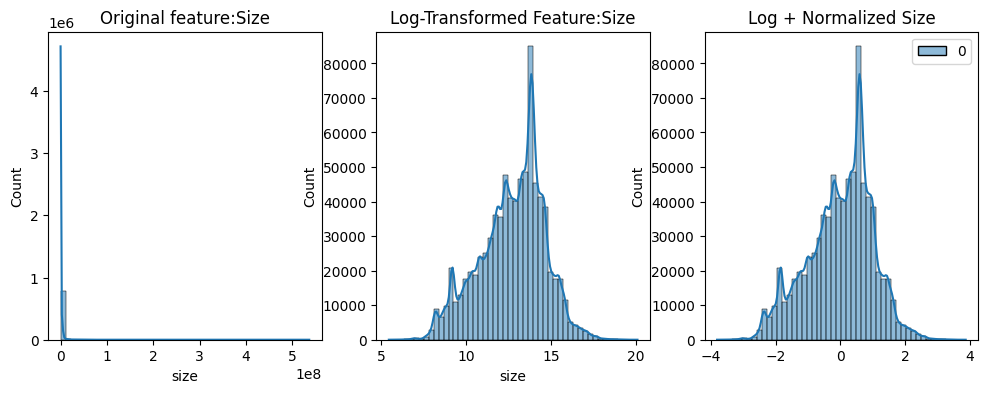

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(df['size'], bins=50,kde=True)
plt.title("Original feature:Size")

plt.subplot(1,3,2)
sns.histplot(np.log1p(df['size']), bins=50, kde=True)
plt.title("Log-Transformed Feature:Size")

plt.subplot(1,3,3)
sns.histplot(StandardScaler().fit_transform(np.log1p(df[['size']])), bins=50, kde=True)
plt.title("Log + Normalized Size")

plt.show()

# Confusion Matrix Heatmap

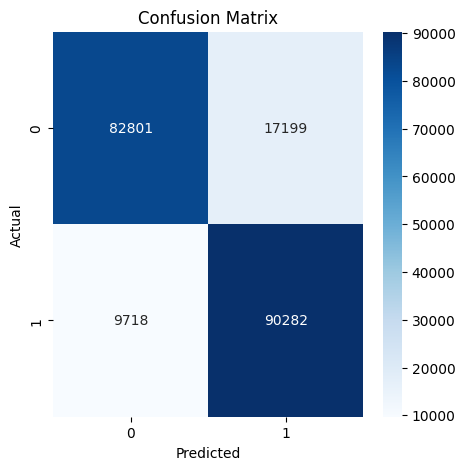

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision/Recall per Class

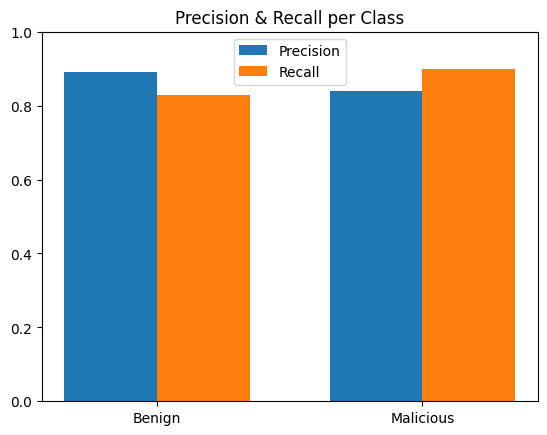

In [86]:
import numpy as np

classes = ['Benign', 'Malicious']
precision = [0.89, 0.84]
recall = [0.83, 0.90]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, precision, width, label='Precision')
ax.bar(x + width/2, recall, width, label='Recall')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0,1)
ax.legend()
plt.title("Precision & Recall per Class")
plt.show()